In [1]:
### IMPORT ALL THE LIBS
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### Load Dataset
df = pd.read_excel(r"C:\Users\shash\OneDrive\Desktop\practices\PROJECTS\Customer-Churn-Prediction-System\data\customer_churn.csv.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
### BASIC  CHECK IN THE DATA SET
print("INFORMATION:",df.info())
print("DESCRIBE:",df.describe())
print("SHAPE:",df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

### Drop Useless Columns

In [5]:
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Reason"
]

df.drop(drop_cols, axis=1, inplace=True)

### WHY? These columns: do not help prediction increase noise may cause leakage Professional ML projects remove such columns.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

### Check Duplicate Rows

In [7]:
df.duplicated().sum()

np.int64(0)

### STEP-1: START EDA  Churn Distribution

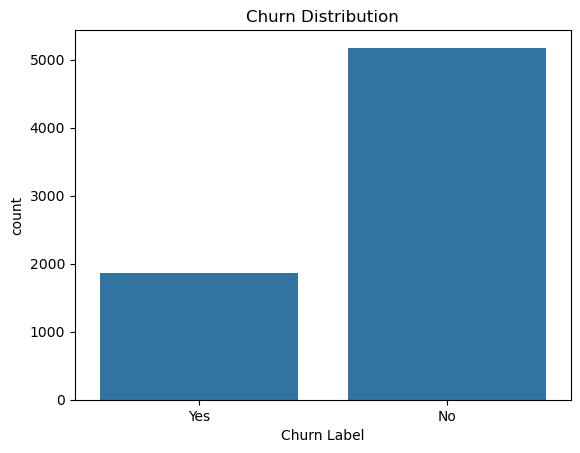

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn Label', data=df)

plt.title("Churn Distribution")

plt.show()

### Churn Percentage

In [9]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Gender vs Churn

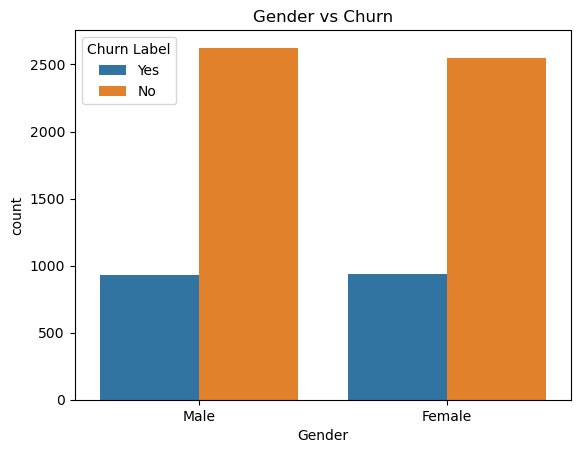

In [10]:
sns.countplot(x='Gender', hue='Churn Label', data=df)

plt.title("Gender vs Churn")

plt.show()

###  Contract vs Churn

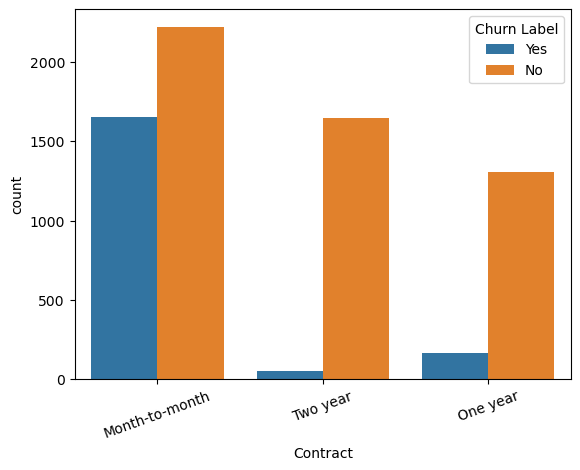

In [11]:
sns.countplot(x='Contract', hue='Churn Label', data=df)

plt.xticks(rotation=20)

plt.show()

### Monthly Charges Distribution

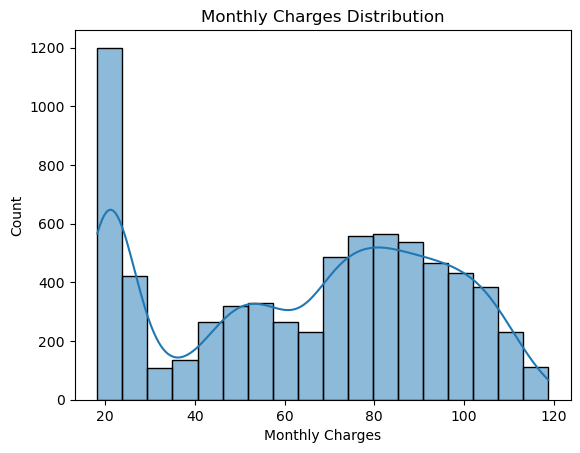

In [12]:
sns.histplot(df['Monthly Charges'], kde=True)

plt.title("Monthly Charges Distribution")

plt.show()

### Tenure vs Churn

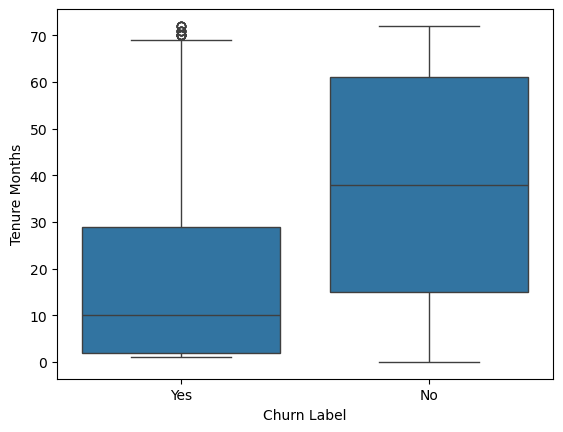

In [13]:
sns.boxplot(
    x='Churn Label',
    y='Tenure Months',
    data=df
)

plt.show()

### STEP-2: Separate Features and Target

In [14]:
X = df.drop("Churn Label", axis=1)

y = df["Churn Label"]

### Convert Target Variable
- models need numerical target

In [15]:
y = y.map({
    "Yes": 1,
    "No": 0
})

In [16]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Churn Label, dtype: int64

### STEP-3:  Identify Numerical and Categorical Columns

In [17]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [18]:
print("Numerical Columns:")
print(num_cols)
print("Categrical Columns:")
print(cat_cols)

Numerical Columns:
Index(['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')
Categrical Columns:
Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges'],
      dtype='object')


### STEP-4: BUILD PIPELINES
- Import Preprocessing Libraries

In [19]:
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

### Numerical Pipeline

In [20]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Categorical Pipeline

In [21]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

### STEP-5: Combine Pipelines

In [22]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

### STEP-6: Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print(X_train.shape)

print(X_test.shape)

(5634, 22)
(1409, 22)


In [25]:
X[cat_cols] = X[cat_cols].astype(str)

### Split Data

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### STEP-7:  MODEL BUILDING
- Import Models + Metrics

In [27]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

###  STEP-8:  MODEL 1 — LOGISTIC REGRESSION
- Create Pipeline

In [28]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

### Train Model

In [29]:
log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges'],
      dtype='object'))])),
                ('model', LogisticRegression())])

### Predictions

In [30]:
y_pred_log = log_model.predict(X_test)

### Accuracy

In [31]:
accuracy_score(y_test, y_pred_log)

1.0

### Classification Report

In [32]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



### ROC-AUC Score

In [33]:
y_prob_log = log_model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob_log)

np.float64(1.0)

### STEP-9: MODEL 2 — RANDOM FOREST
- Create RF Pipeline

In [34]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

### Train RF Model

In [35]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncode...wn='ignore'))]),
                                                  Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges'],
      dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

### Predictions

In [36]:
y_pred_rf = rf_model.predict(X_test)

### Accuracy

In [37]:
accuracy_score(y_test, y_pred_rf)

0.9900638750887154

### Classification Report

In [38]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1009
           1       1.00      0.96      0.98       400

    accuracy                           0.99      1409
   macro avg       0.99      0.98      0.99      1409
weighted avg       0.99      0.99      0.99      1409



### ROC-AUC

In [39]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob_rf)

np.float64(0.9999256689791873)

### STEP-10: MODEL 3 — XGBOOST
- Create XGBoost Pipeline

In [40]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

### Train XGBoost

In [41]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncode...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

### Predictions

In [42]:
y_pred_xgb = xgb_model.predict(X_test)

###  Accuracy

In [43]:
accuracy_score(y_test, y_pred_xgb)

1.0

### Classification Report

In [44]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



### ROC-AUC

In [45]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob_xgb)

np.float64(1.0)

### STEP-11: Hyperparameter Tuning

### hyperparameters
- Example for Random Forest:
- number of trees
- max depth
- min samples split
- Instead of manually guessing,
- we use:
- RandomizedSearchCV
-to automatically find better combinations.
- tuning
- cross-validation
- optimization

### TUNE Random Forest

### Import RandomizedSearchCV

In [46]:
from sklearn.model_selection import RandomizedSearchCV

### Create Random Forest Pipeline

In [47]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

### Create Parameter Grid

In [48]:
param_grid = {
    "model__n_estimators": [100, 200, 300],

    "model__max_depth": [5, 10, 20, None],

    "model__min_samples_split": [2, 5, 10],

    "model__min_samples_leaf": [1, 2, 4]
}

In [49]:
param_grid

{'model__n_estimators': [100, 200, 300],
 'model__max_depth': [5, 10, 20, None],
 'model__min_samples_split': [2, 5, 10],
 'model__min_samples_leaf': [1, 2, 4]}

### Create RandomizedSearchCV

In [50]:
random_search = RandomizedSearchCV(
    estimator=rf_model,

    param_distributions=param_grid,

    n_iter=10,

    cv=5,

    scoring='accuracy',

    random_state=42,

    n_jobs=-1
)

In [51]:
random_search

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_f...
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges'],
      dtype='object'))])),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10, 20, None],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='accuracy')

### Train Tuning Process

In [52]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_f...
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges'],
      dtype='object'))])),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10, 20, None],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='accuracy')

### Best Parameters

In [53]:
random_search.best_params_

{'model__n_estimators': 300,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_depth': None}

### Best Score

In [54]:
random_search.best_score_

np.float64(0.9875754332932493)

### cross-validation accuracy

### Best Model

In [55]:
best_rf_model = random_search.best_estimator_

### optimized Random Forest model

### Predictions Using Best Model

In [56]:
y_pred_best_rf = best_rf_model.predict(X_test)

## Accuracy

In [57]:
accuracy_score(y_test, y_pred_best_rf)

0.9907735982966643

In [58]:
print(classification_report(
    y_test,
    y_pred_best_rf
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1009
           1       1.00      0.97      0.98       400

    accuracy                           0.99      1409
   macro avg       0.99      0.98      0.99      1409
weighted avg       0.99      0.99      0.99      1409



In [59]:
y_prob_best_rf = best_rf_model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob_best_rf)

np.float64(0.9999392963330029)

### STEP-12: Feature Importance Analysis

- Get Random Forest Model
- Get Feature Names

In [60]:
rf_final_model = best_rf_model.named_steps["model"]

In [61]:
encoded_cat_features = preprocessor.named_transformers_[
    "cat"
].named_steps[
    "encoder"
].get_feature_names_out(cat_cols)

## Combine Numerical + Encoded Features

In [62]:
all_features = np.concatenate([
    num_cols,
    encoded_cat_features
])

### Extract Feature Importance

In [63]:
importance = rf_final_model.feature_importances_
importance

array([4.52101618e-02, 3.09280518e-02, 3.17281842e-01, ...,
       2.81987477e-08, 4.85198375e-05, 3.64809523e-05])

### Create Importance DataFrame

In [64]:
feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importance
})

### Sort Features

In [65]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

### Top Important Features

In [66]:
feature_importance_df.head(10)

,Feature,Importance
2,Churn Value,0.317282
3,Churn Score,0.151520
0,Tenure Months,0.045210
1,Monthly Charges,0.030928
4,CLTV,0.027264
39,Contract_Month-to-month,0.024862
21,Online Security_No,0.015991
30,Tech Support_No,0.015705
46,Payment Method_Electronic check,0.012583
19,Internet Service_Fiber optic,0.011978


### STEP-13: Visualize Feature Importance

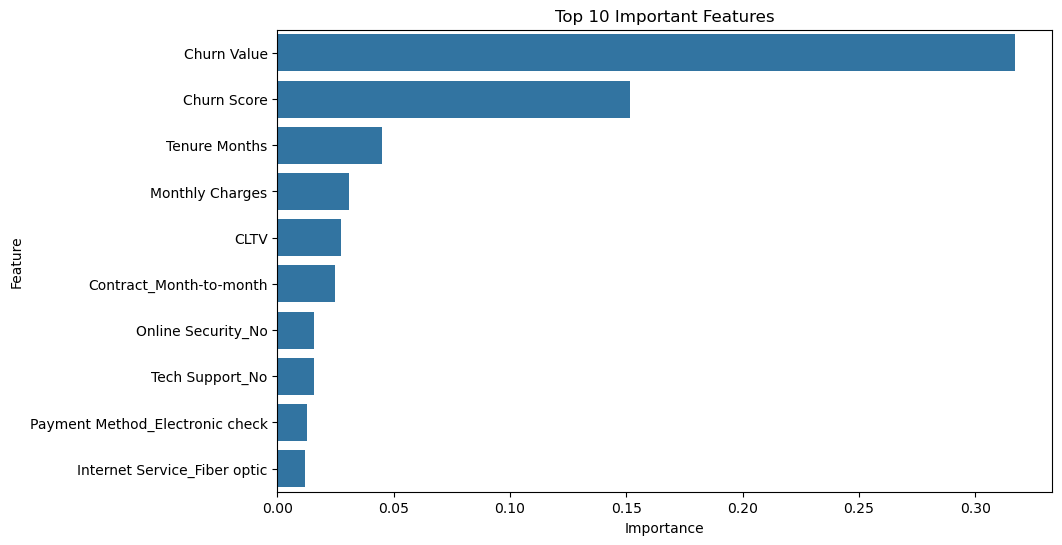

In [67]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

## Customers with month-to-month contracts and higher monthly charges showed higher churn probability.
## Longer tenure customers were less likely to churn.

### STEP-14: Save Best Model

In [68]:
import joblib

joblib.dump(
    best_rf_model,
    "../models/best_rf_model.pkl"
)



['../models/best_rf_model.pkl']

In [ ]:
import sys

print(sys.executable)